# Exploratory Data Analysis (EDA)

## Import Libraries & Load Dataset

In [288]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_ecommerce_sales_data.csv")
df.head()

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Payment_Method,Status,Total,Quantity,Price
0,100,Customer_100,ORD-41285,2024-11-22,Blender,Home,Cash on Delivery,Shipped,114.00,3.0,38.00
1,102,Customer_102,ORD-84355,2024-12-23,Tennis Racket,Sports,PayPal,Delivered,389.05,1.0,389.05
2,103,Customer_103,ORD-57811,2025-03-19,Science,Books,PayPal,Processing,1169.60,5.0,233.92
3,104,Customer_104,ORD-93614,2025-10-20,Biography,Books,Cash on Delivery,Processing,552.51,1.0,552.51
4,105,Customer_105,ORD-22442,2024-11-20,Tennis Racket,Sports,Cash on Delivery,Cancelled,366.18,3.0,122.06


## Dataset Overview and Quality Assessment

This section provides a general overview of the dataset structure and data quality.

### Dataset Shape


In [289]:
df.shape

(84, 11)

### Dataset Info

In [290]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              84 non-null     int64  
 1   Customer_Name   84 non-null     str    
 2   Order_ID        84 non-null     str    
 3   Order_Date      84 non-null     str    
 4   Product         84 non-null     str    
 5   Category        84 non-null     str    
 6   Payment_Method  84 non-null     str    
 7   Status          84 non-null     str    
 8   Total           84 non-null     float64
 9   Quantity        84 non-null     float64
 10  Price           84 non-null     float64
dtypes: float64(3), int64(1), str(7)
memory usage: 7.3 KB


### Descriptive Statistics

In [291]:
df.describe()

,ID,Total,Quantity,Price
count,84.000000,84.000000,84.00000,84.000000
mean,150.285714,1570.641310,3.02381,512.878929
std,28.267471,1174.974981,1.52075,262.337104
min,100.000000,40.950000,1.00000,38.000000
25%,126.750000,687.777500,2.00000,273.000000
50%,150.500000,1300.930000,3.00000,530.790000
75%,174.250000,2204.030000,4.25000,737.940000
max,199.000000,4722.700000,5.00000,944.540000


### Missing Values Overview

In [292]:
df.isnull().sum()

ID                0
Customer_Name     0
Order_ID          0
Order_Date        0
Product           0
Category          0
Payment_Method    0
Status            0
Total             0
Quantity          0
Price             0
dtype: int64

### Duplicate Records Check

In [293]:
df.duplicated().sum()

np.int64(0)

## Numerical Variables Analysis

### Distribution of Numerical Features  
The following histograms show how the numerical variables (Total, Quantity, Price) are distributed in the dataset.


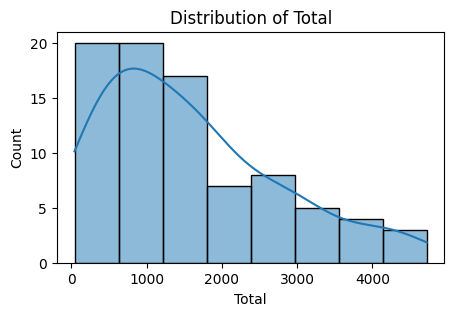

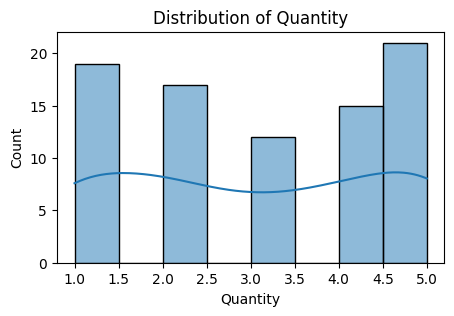

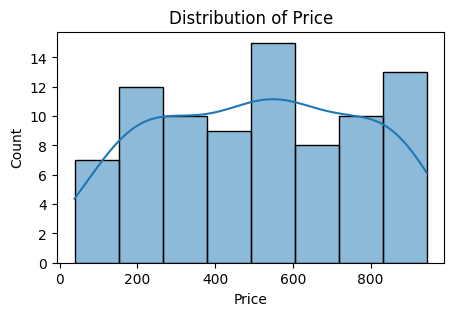

In [294]:
num_cols = ["Total", "Quantity", "Price",]

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

#### Coclusion
All three numerical features show clear patterns, with lower values appearing more frequently than higher ones.


### Boxplots of Numerical Features  
The following boxplots show the distribution, spread, and potential outliers for the numerical variables (Total, Quantity, Price).


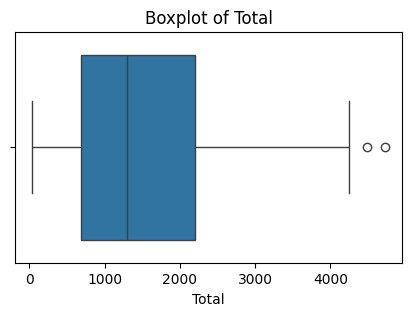

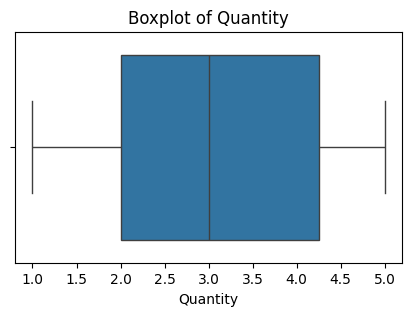

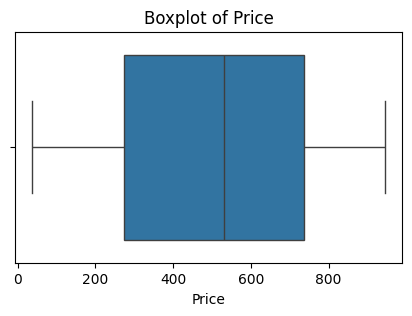

In [295]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


#### Conclusion  
The boxplots reveal the overall spread of each numerical feature and highlight the presence of outliers where applicable.


## Categorical Variables Analysis

 
The following charts show how the categorical features (Category, Payment Method, Status) are distributed in the dataset.


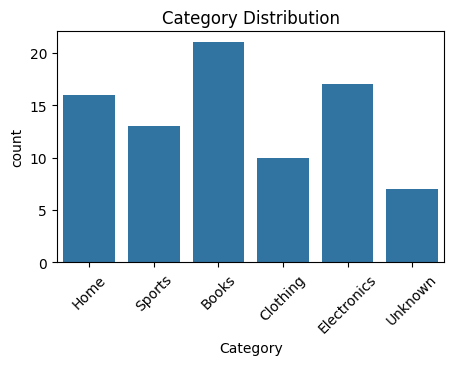

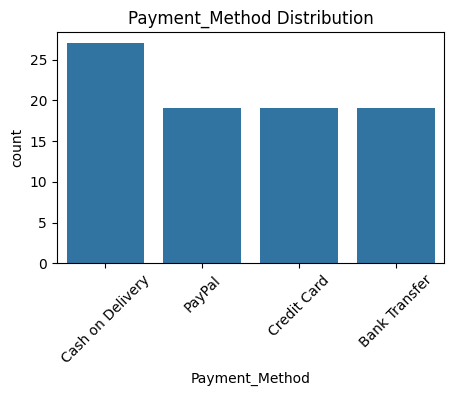

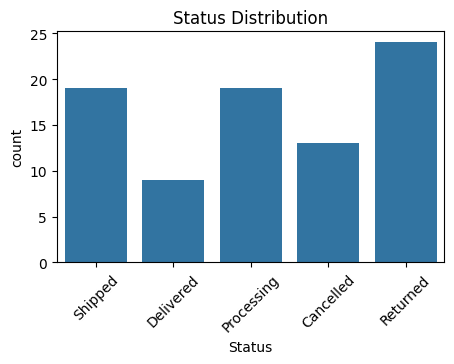

In [296]:
cat_cols = ["Category", "Payment_Method", "Status"]

for col in cat_cols:
    plt.figure(figsize=(5,3))
    sns.countplot(data=df, x=col)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
    plt.show()


# Business Insights

### Revenue by Category  
This chart shows the total revenue generated by each product category.


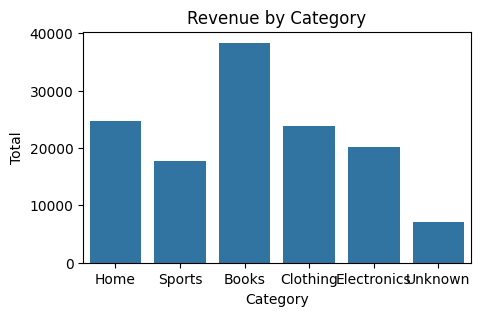

In [297]:
plt.figure(figsize=(5,3))
sns.barplot(data=df, x="Category", y="Total", estimator="sum", errorbar=None)
plt.title("Revenue by Category")
plt.show()


#### Conclusion  
Books generate the highest revenue, while the Unknown category contributes the least.


### Payment Method Distribution  
This chart shows how frequently each payment method is used in the dataset.


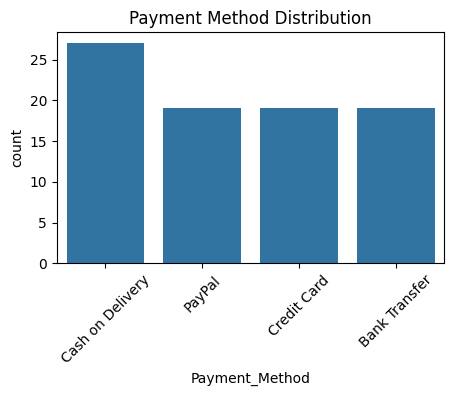

In [298]:
plt.figure(figsize=(5,3))
sns.countplot(data=df, x="Payment_Method")
plt.title("Payment Method Distribution")
plt.xticks(rotation=45)
plt.show()


#### Conclusion  
Cash on Delivery is the most commonly used payment method.


### Order Status Distribution  
This chart shows how frequently each order status appears in the dataset.


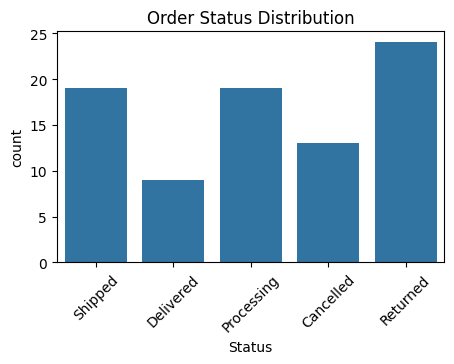

In [299]:
plt.figure(figsize=(5,3))
sns.countplot(data=df, x="Status")
plt.title("Order Status Distribution")
plt.xticks(rotation=45)
plt.show()


#### Conclusion  
Returned orders are the most common, while Delivered is the least frequent.


### Monthly Revenue Trend  
This line chart shows how total revenue changes over time on a month‑to‑month basis.


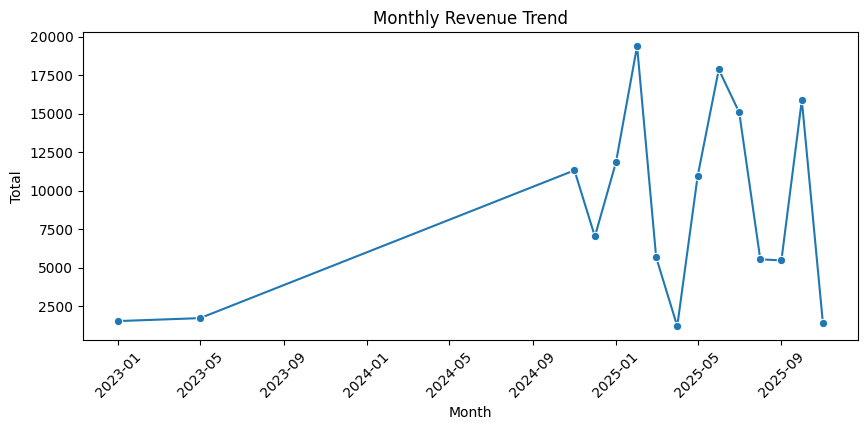

In [300]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["Month"] = df["Order_Date"].dt.to_period("M").dt.to_timestamp()
monthly = df.groupby("Month")["Total"].sum().reset_index()

plt.figure(figsize=(10,4))
sns.lineplot(data=monthly, x="Month", y="Total", marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.show()



#### Conclusion  
Revenue shows clear month‑to‑month fluctuations, with noticeable peaks and dips across the observed period.


## Correlation Heatmap  
This heatmap shows the relationships between the numerical variables in the dataset.


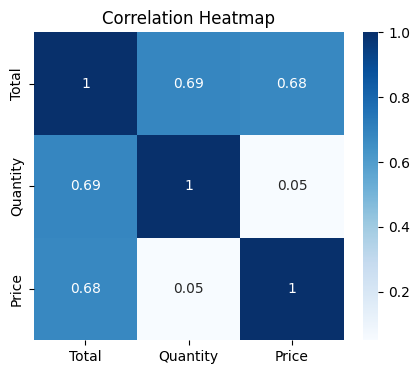

In [301]:
plt.figure(figsize=(5,4))
sns.heatmap(df[["Total", "Quantity", "Price"]].corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()


#### Conclusion  
Total is strongly correlated with both Quantity and Price, while Quantity and Price show almost no correlation.


## Key Findings

- The dataset is generally clean and well‑structured, with no missing values or duplicates.
- Revenue is primarily driven by the Books, Home, and Clothing categories, while the Unknown category contributes minimally.
- Customer behavior shows a strong preference for Cash on Delivery over digital payment methods.
- Returned orders represent a significant portion of all transactions, indicating potential issues with product quality, customer expectations, or logistics.
- Total revenue is influenced by both Quantity and Price, while Quantity and Price themselves show almost no relationship.
- Monthly revenue fluctuates noticeably over time, with clear periods of growth and decline, suggesting seasonal or campaign‑driven patterns.

